In [ ]:
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

def read_video_into_numpy(filename):
  cap = cv2.VideoCapture(filename)
  frames = []
  while cap.isOpened():
    ret, frame = cap.read()
    # if frame is read correctly ret is True
    if not ret:
      print("Can't receive frame (stream end?). Exiting ...")
      break

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame)

  cap.release()
  video = np.stack(frames, axis=0)#converts to numpy array(T,H,W,C)
  video = np.transpose(video, (1,2,3,0))#(T,H,W,C)->(H,W,C,T)
  return frames

In [ ]:
# detect corners in an image
def detect_corners(img):
  dst = cv2.cornerHarris(img, 2, 3, 0.04)
  y,x = np.where(dst > 0.1*dst.max()) # tuple of locations
  return x, y

In [ ]:
# construct a gaussian pyramid
def gaussian(img, lvl):
  lower = img.copy()
  gauss = [lower]
  for i in range(lvl):
    lower = cv2.pyrDown(lower)
    gauss.append(lower)
  return gauss

In [ ]:
# bilinear interp helper func
def bilinear(img, px, py, x, y):
  xx, yy = np.meshgrid(px, py, sparse = True)
  xx = xx.astype(float) + x
  yy = yy.astype(float) + y
  x0 = np.floor(xx).astype(int)
  y0 = np.floor(yy).astype(int)
  x1 = x0 + 1
  y1 = y0 + 1
  w1 = (x1 - xx) * (y1 - yy)
  w2 = (x1 - xx) * (yy - y0)
  w3 = (xx - x0) * (y1 - yy)
  w4 = (xx - x0) * (yy - y0)
  # separately calculates RGB values
  r = w1 * img[y0, x0, 0] + w2 * img[y1, x0, 0] + w3 * img[y0, x1, 0] + w4 * img[y1, x1, 0]
  g = w1 * img[y0, x0, 1] + w2 * img[y1, x0, 1] + w3 * img[y0, x1, 1] + w4 * img[y1, x1, 1]
  b = w1 * img[y0, x0, 2] + w2 * img[y1, x0, 2] + w3 * img[y0, x1, 2] + w4 * img[y1, x1, 2]
  return np.stack((r, g, b), axis=2)


In [ ]:
def lucas_kanade1(ima, imb, loc, K):
  # get gauss pyramids
  gaussa = gaussian(ima, 4)
  gaussb = gaussian(imb, 4)
  w = 5
  F = np.zeros(np.shape(loc)) #init F

  # iterate thru each level of pyramid
  for l in range(len(gaussa)-1, -1, -1):
    # get x, y gradients
    ax = cv2.Sobel(gaussa[l], -1, 1, 0, ksize= 3)
    ay = cv2.Sobel(gaussa[l], -1, 0, 1, ksize= 3)
    locl = (loc/(2**l)).astype(int)

    # go through each tracked point
    for i in range(len(locl[0])):
      # get size of image
      lenx = np.shape(gaussa[l])[1]
      leny = np.shape(gaussa[l])[0]
      # make sure that point is not outside of image
      if locl[0, i] >= 0 and locl[0, i] < lenx and locl[1, i] >= 0 and locl[1, i] < leny:
        # get window bounds, cut off at the edge of image
        px1 = max(locl[0, i] - w, 0)
        py1 = max(locl[1, i] - w, 0)
        px2 = min(locl[0, i] + w + 1, lenx)
        py2 = min(locl[1, i] + w + 1, leny)
        # get Ix and Iy vals for window
        Ix = ax[py1:py2, px1:px2].flatten()
        Iy = ay[py1:py2, px1:px2].flatten()
        # construct G, sum of element-wise product is just dot product
        G = np.array([[np.dot(Ix, Ix), np.dot(Ix,Iy)],[np.dot(Ix, Iy), np.dot(Iy, Iy)]])
        for k in range(K):
          # limit fx and fy window to the bounds of the image
          fx = min(max(F[0][i], -px1), lenx - px2 - 1)
          fy = min(max(F[1][i], -py1), leny - py2 - 1)
          # use bilinear interp for It
          It = (gaussa[l][py1:py2, px1:px2] - bilinear(gaussb[l], range(px1, px2), range(py1, py2), fx, fy))
          b = np.array([np.dot(It.flatten(), Ix), np.dot(It.flatten(), Iy)])
          dx = np.matmul(np.linalg.pinv(G),b.T)

          F[0][i] += dx[0]
          F[1][i] += dx[1]

    if l > 0:
      # scale F up, pyrdown does not exactly scale by 2, ensure that image size
      # does not distort
      F[0] = F[0] * (np.shape(gaussb[l-1])[0]/np.shape(gaussa[l])[0])
      F[1] = F[1] * (np.shape(gaussb[l-1])[1]/np.shape(gaussa[l])[1])

  # remove points that do not have movement
  idxs = [i for i in range(len(F[0])) if np.abs(F[0][i]) > .01 or np.abs(F[1][i]) > .01]
  locb = np.array([loc[0][idxs] + F[0][idxs], loc[1][idxs] + F[1][idxs]])

  return locb



In [ ]:
def circle(img : np.ndarray, points):
  im = img.copy()
  for i in range(len(points[0])):
    im = cv2.circle(im, (points[:,i]), 2, (255,0,0), -1)
  return im

In [ ]:



frames = read_video_into_numpy('cars.mp4')


print(np.shape(frames[0]))
corners = np.array(detect_corners(cv2.cvtColor(frames[0], cv2.COLOR_RGB2GRAY)))
circled = circle(frames[0].copy(), corners)
im_list = [circled]



Can't receive frame (stream end?). Exiting ...
(360, 640, 3)


In [ ]:
for i in range(1, len(frames)):
  corners = lucas_kanade1(frames[i-1]/255.0, frames[i]/255.0, corners, 5)
  im_list.append(circle(frames[i].copy(), corners.astype(int)))

In [ ]:
# create gif
import imageio
imageio.mimsave('tracking.gif', im_list, fps=10)



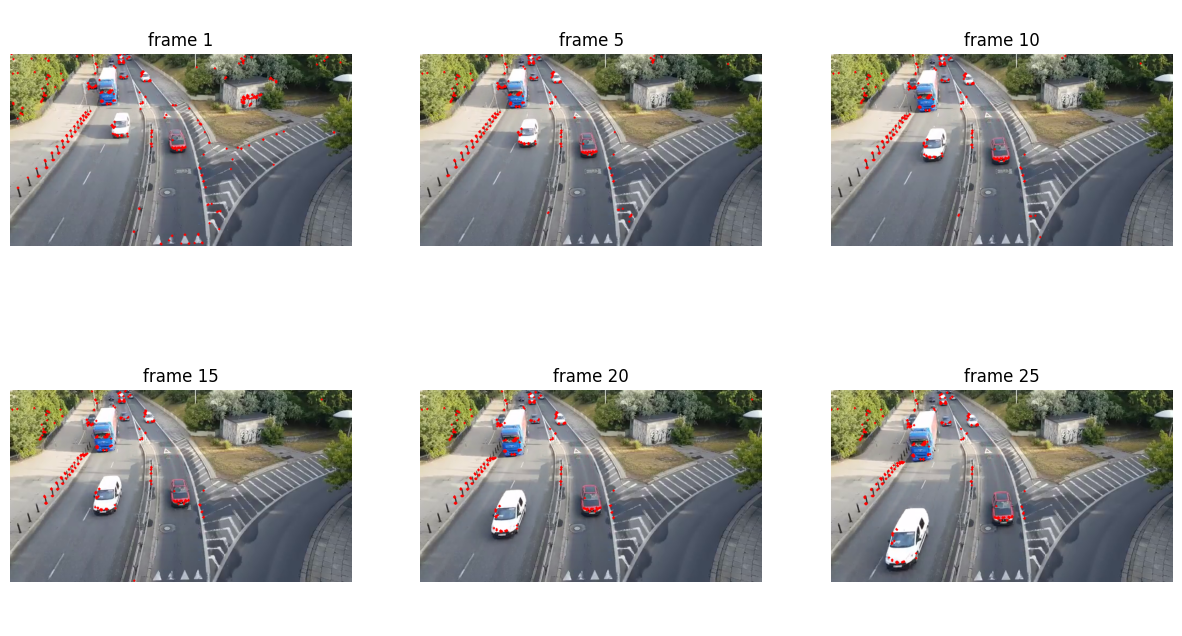

In [ ]:
plt.subplots(figsize=(15, 8))
plt.axis('off')
plt.subplot(2, 3, 1)
plt.imshow(im_list[0])
plt.axis('off')
plt.title("frame 1")
for k in range(4, 25, 5):
  plt.subplot(2, 3, int((k+1)/5) + 1)
  plt.imshow(im_list[k])
  plt.axis('off')
  plt.title("frame " + str(k + 1))
plt.show()

Results: https://drive.google.com/file/d/1xVsnd9RpIgGV4Ml1GzjilV7m35YRbsOL/view?usp=sharing

